**Optimization Model: Optimal Storage Arbitrage under Net Metering (LP)**





# Battery Arbitrage Model

## Objective

 Minimize the total electricity transaction cost over the horizon:

$$ min_{x,z}\sum_{k=1}^{N} z_k
$$

## Constraints

### 1. Piecewise linear electricity cost
$$
z_k \ge \frac{\text{real}_k}{\eta_{ch}}x_k,\qquad k=1,\dots,N
$$

$$
z_k \ge \kappa\,\text{real}_k\,\eta_{dis}\,x_k,\qquad k=1,\dots,N
$$

### 2. Battery state-of-charge upper bound
$$ \sum_{i=1}^{k} x_i \le b_{\max}-b_0,\qquad k=1,\dots,N
$$

### 3. Battery state-of-charge lower bound
$$
-\sum_{i=1}^{k} x_i \le b_0-b_{\min},\qquad k=1,\dots,N
$$

### 4. Charge/discharge rate limits
$$
\Delta_{\min}*h \le x_k \le \Delta_{\max}*h,\qquad k=1,\dots,N
$$

## Interpretation

This model performs battery energy arbitrage by shifting energy across time:
- charging during low-price periods,
- discharging during high-price periods,
- while respecting battery energy and power constraints.

Import lybraries

In [174]:
import numpy as np
from scipy.optimize import linprog
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt


# Load electricity price and (inelastic load - renewable generation) data
# Assuming that 'real' is the load_price_data
# Replace this with actual load_price_data if available
#load_price_data = np.loadtxt('Load_price_data.csv')

In [175]:

# df = pd.read_csv('load_price_data.csv')
df = pd.read_csv('data.csv')
load = df[df.columns[0]]
real = df[df.columns[1]]

N = len(load)  # Length of horizon in number of samples
# print(f"co to jest to n: {N}")

##Data visualization

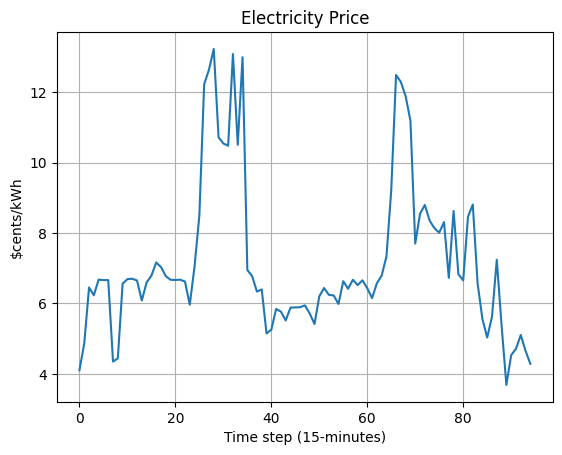

In [176]:
 plt.plot(real)
 plt.title("Electricity Price")
 plt.xlabel("Time step (15-minutes)")
 plt.ylabel("$cents/kWh")
 plt.grid(True)
 plt.show()

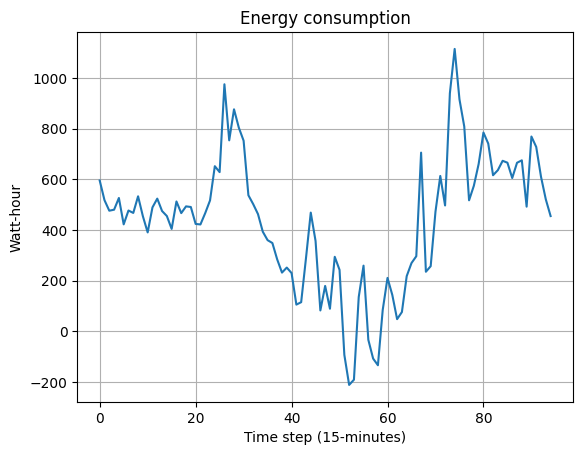

In [177]:
  plt.plot(load)
  plt.title("Energy consumption")
  plt.xlabel("Time step (15-minutes)")
  plt.ylabel("Watt-hour")
  plt.grid(True)
  plt.show()

# Unit of electricity price cents per kWh
# Unit of load is kWh
#Parameters

In [178]:

e_ch = 0.95  # Charging efficiency
e_dis = 0.95  # Discharging efficiency
del_max = 100  # Maximum charging rate
del_min = -del_max  # Minimum discharging rate
b_0 = 1000  # Initial battery capacity
b_max = 2000  # Maximum battery capacity
b_min = 200  # Minimum permissible battery capacity
h = 0.25  # Sampling time
kappa = 0.0  # the ratio of selling price and buying price

Electricity price

In [179]:

real_buy = real / e_ch
real_sell = kappa * real * e_dis

A_buy = np.diag(real_buy)
A_sell = np.diag(real_sell)
A_minus = -1 * np.eye(N)
A_zero = np.zeros((N, N))

In [180]:
print(A_buy[:,:5])

[[4.32210526 0.         0.         0.         0.        ]
 [0.         5.12105263 0.         0.         0.        ]
 [0.         0.         6.79368421 0.         0.        ]
 [0.         0.         0.         6.56105263 0.        ]
 [0.         0.         0.         0.         7.02736842]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0

# LP matrix formulation

In [181]:

A_upper = np.hstack((A_buy, A_minus))
A_lower = np.hstack((A_sell, A_minus))
A_eq1 = np.hstack((np.tril(np.ones((N, N)), -1) + np.eye(N), A_zero))
A_eq2 = np.hstack((-np.tril(np.ones((N, N)), -1) - np.eye(N), A_zero))

A = np.vstack((A_upper, A_lower, A_eq1, A_eq2))

b_upper = np.zeros(2 * N)
b_lower = (b_max - b_0) * np.ones(N)
b_eq = (b_0 - b_min) * np.ones(N)

b = np.concatenate((b_upper, b_lower, b_eq))

lb = np.hstack((del_min * h * np.ones(N), -100000 * np.ones(N)))
ub = np.hstack((del_max * h * np.ones(N), 100000 * np.ones(N)))

f = np.hstack((np.zeros(N), np.ones(N)))


# Solve the linear programming problem

In [182]:


res = linprog(c=f, A_ub=A, b_ub=b, bounds=list(zip(lb, ub)))

x_state = res.x[:N]
x = x_state

# Calculate profit from arbitrage

In [183]:
profit_only_arbitrage = np.sum(
    kappa * real * e_dis * np.maximum(-x, 0)
    - (real / e_ch) * np.maximum(x, 0)
) / 1000

In [184]:
profit_only_arbitrage = np.sum(load * np.maximum(x, 0) / e_ch - kappa * load * np.maximum(-x, 0) * e_dis) / 1000

x_adj = x / b_max

In [185]:
# Solve the linear programming problem
res = linprog(c=f, A_ub=A, b_ub=b, bounds=list(zip(lb, ub)), method='highs')

if res.success:
    x_state = res.x[:N]
    x = x_state

    print(f"Optimal objective cost = {res.fun:.6f}")

    # Current profit expression from your code
    profit_only_arbitrage = np.sum(
        load * np.maximum(x, 0) / e_ch
        - kappa * load * np.maximum(-x, 0) * e_dis
    ) / 1000

    print(f"Profit only arbitrage = {profit_only_arbitrage:.6f}")

    x_adj = x / b_max
else:
    print("Optimization failed:", res.message)

Optimal objective cost = 0.000000
Profit only arbitrage = 0.000000


Solver success: True
Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Objective cost (sum z): 0.0
Arbitrage profit: 0.0


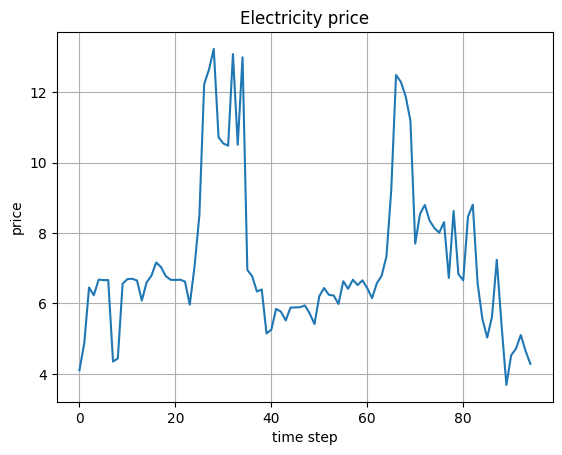

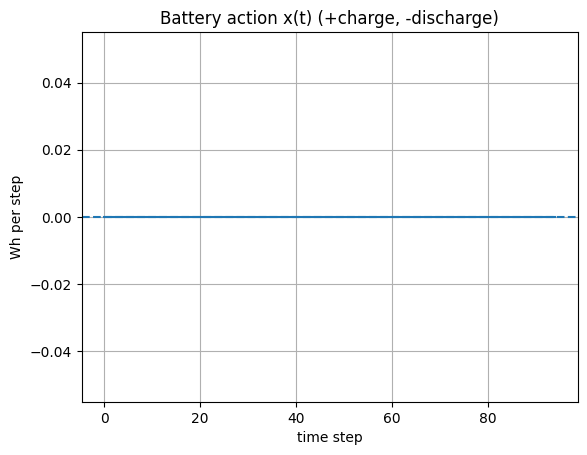

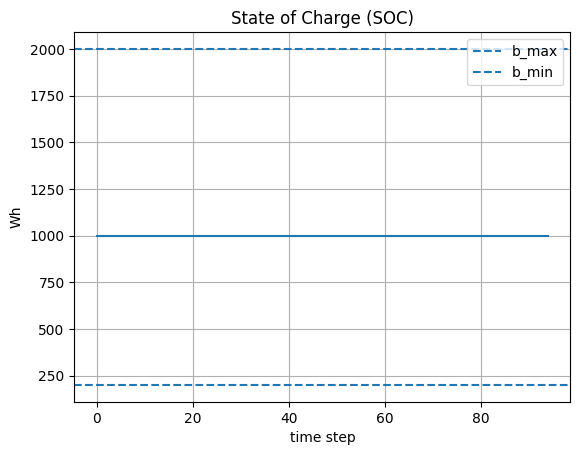

In [186]:

print("Solver success:", res.success)
print("Status:", res.message)
print("Objective cost (sum z):", res.fun)

x = res.x[:N]
soc = b_0 + np.cumsum(x)

# Correct profit
profit_only_arbitrage = np.sum(
    kappa * real * e_dis * np.maximum(-x, 0)
    - (real / e_ch) * np.maximum(x, 0)
) / 1000

print("Arbitrage profit:", profit_only_arbitrage)

# Plots
plt.figure()
plt.plot(real)
plt.title("Electricity price")
plt.xlabel("time step")
plt.ylabel("price")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(x)
plt.axhline(0, linestyle='--')
plt.title("Battery action x(t) (+charge, -discharge)")
plt.xlabel("time step")
plt.ylabel("Wh per step")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(soc)
plt.axhline(b_max, linestyle='--', label="b_max")
plt.axhline(b_min, linestyle='--', label="b_min")
plt.title("State of Charge (SOC)")
plt.xlabel("time step")
plt.ylabel("Wh")
plt.legend()
plt.grid(True)
plt.show()

In [187]:
if res.success:
    x = res.x[:N]
    soc = b_0 + np.cumsum(x)

    # Available flexibility
    power_flex_per_step = (del_max - del_min) * h
    energy_flex = b_max - b_min

    # Activated flexibility
    charged_energy = np.sum(np.maximum(x, 0))
    discharged_energy = np.sum(np.maximum(-x, 0))
    total_shifted_energy = np.sum(np.abs(x))

    # Time-varying flexibility
    upward_flex = np.minimum(del_max * h, b_max - soc)
    downward_flex = np.minimum(abs(del_min) * h, soc - b_min)

    print(f"Power flexibility per step: {power_flex_per_step:.2f} Wh")
    print(f"Usable energy flexibility: {energy_flex:.2f} Wh")
    print(f"Total charged energy: {charged_energy:.2f} Wh")
    print(f"Total discharged energy: {discharged_energy:.2f} Wh")
    print(f"Total shifted energy: {total_shifted_energy:.2f} Wh")

Power flexibility per step: 50.00 Wh
Usable energy flexibility: 1800.00 Wh
Total charged energy: 0.00 Wh
Total discharged energy: 0.00 Wh
Total shifted energy: 0.00 Wh


####Flexibility envelops

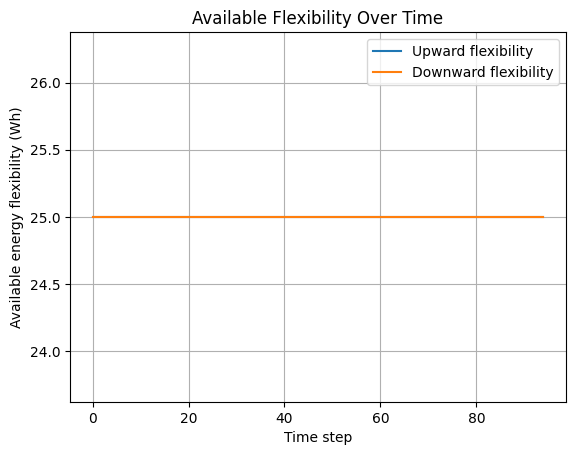

In [188]:

plt.figure()
plt.plot(upward_flex, label='Upward flexibility')
plt.plot(downward_flex, label='Downward flexibility')
plt.title('Available Flexibility Over Time')
plt.xlabel('Time step')
plt.ylabel('Available energy flexibility (Wh)')
plt.legend()
plt.grid(True)
plt.show()

# Optimization Model: Optimal Storage Arbitrage under Net Metering (LP)

We optimize the operation of a battery connected behind-the-meter for a household with net load  
$$
z_t = d_t - r_t
$$
where \(d_t\) is inelastic demand and \(r_t\) is renewable generation (e.g., PV).  
Electricity has a time-varying buying price \(p_b(t)\). Under net-metering, exported energy is compensated at selling price
$$
p_s(t) = \kappa\, p_b(t), \quad 0 \le \kappa \le 1 .
$$



## Decision Variables

For each time step \(t = 1,\dots,T\):

- \(x_t\): battery energy change (positive = charging, negative = discharging)
- \(u_t\): epigraph (auxiliary) variable representing the cost contribution at time \(t\)

Stacked variable:
$$
\mathbf{y} = [x_1,\dots,x_T,\; u_1,\dots,u_T]^T \in \mathbb{R}^{2T}.
$$

---

## Battery Model

### Charging/discharging split
$$
[x_t]^+ = \max(x_t,0), \qquad [x_t]^- = \max(-x_t,0).
$$

### Battery impact on grid exchange (efficiency losses)
Charging increases grid import by \(x_t/\eta_{ch}\), discharging reduces import (or increases export) by \(\eta_{dis}[x_t]^-\).  
Define the storage contribution seen at the meter:
$$
s_t = \frac{1}{\eta_{ch}}[x_t]^+ - \eta_{dis}[x_t]^- .
$$

### Net grid exchange with storage
$$
\ell_t = z_t + s_t .
$$

### State of charge (SOC)
$$
b_t = b_0 + \sum_{\tau=1}^{t} x_\tau ,
$$
with capacity constraints:
$$
b_{\min} \le b_t \le b_{\max}, \qquad \forall t .
$$

### Power/energy rate constraints
For sampling time \(dt\):
$$
\Delta_{\min} dt \le x_t \le \Delta_{\max} dt,\qquad \forall t .
$$

---

## Net-Metering Cost (Piecewise Linear)

The cost at time \(t\) is:
$$
C_t(\ell_t) = p_b(t)\,[\ell_t]^+ - p_s(t)\,[-\ell_t]^+ .
$$

Because (ℓ_t) depends on \(x_t\) through efficiencies and sign changes, the resulting cost in terms of \(x_t\) is convex and piecewise linear, and can be written as the maximum of four affine functions (four segments).

We use an epigraph variable \(u_t\) such that:
$$
u_t \ge g_{t,1}(x_t),\;
u_t \ge g_{t,2}(x_t),\;
u_t \ge g_{t,3}(x_t),\;
u_t \ge g_{t,4}(x_t).
$$

These four linear inequalities (segments) are:

$$
\frac{p_b(t)}{\eta_{ch}}x_t - u_t \le -z_t\,p_b(t)
$$
$$
p_b(t)\eta_{dis}\,x_t - u_t \le -z_t\,p_b(t)
$$
$$
\frac{p_s(t)}{\eta_{ch}}x_t - u_t \le -z_t\,p_s(t)
$$
$$
p_s(t)\eta_{dis}\,x_t - u_t \le -z_t\,p_s(t)
$$

(These correspond to different combinations of importing/exporting and charging/discharging.)

---

## Optimization Problem (Linear Program)

$$
\min_{x,u} \sum_{t=1}^{T} u_t
$$

subject to:

### (1) Four-segment epigraph constraints (for all \(t\))
$$
\frac{p_b(t)}{\eta_{ch}}x_t - u_t \le -z_t\,p_b(t)
$$
$$
p_b(t)\eta_{dis}\,x_t - u_t \le -z_t\,p_b(t)
$$
$$
\frac{p_s(t)}{\eta_{ch}}x_t - u_t \le -z_t\,p_s(t)
$$
$$
p_s(t)\eta_{dis}\,x_t - u_t \le -z_t\,p_s(t)
$$

### (2) SOC constraints (for all \(t\))
$$
\sum_{\tau=1}^{t} x_\tau \le b_{\max}-b_0
$$
$$
-\sum_{\tau=1}^{t} x_\tau \le b_0-b_{\min}
$$

### (3) Power/rate constraints (for all \(t\))
$$
\Delta_{\min} dt \le x_t \le \Delta_{\max} dt .
$$

---

## Outputs / Performance Metrics

### Baseline bill without storage
$$
C_{\text{nom}} = \sum_{t=1}^{T}\left(p_b(t)[z_t]^+ - p_s(t)[-z_t]^+\right)
$$

### Bill with storage
$$
C_{\text{bat}} = \sum_{t=1}^{T}\left(p_b(t)[\ell_t]^+ - p_s(t)[-\ell_t]^+\right)
$$

### Arbitrage gain (savings)
$$
\Pi = C_{\text{nom}} - C_{\text{bat}} .
$$

---

## Sensitivity Parameter

We vary \(\kappa\) in:
$$
\kappa \in \{1,\;0.75,\;0.5,\;0.25,\;0\}
$$
to study how storage value changes when export compensation decreases.

In [189]:


# Load data from CSV
df = pd.read_csv('data.csv')
load = df.iloc[:, 0].to_numpy().squeeze()   # net load = demand - renewable generation
real = df.iloc[:, 1].to_numpy().squeeze()   # electricity buying price

N = len(real)

In [190]:
# Unit of electricity price: cents per kWh
# Unit of load: kWh
# Battery parameters
e_ch = 0.95          # Charging efficiency
e_dis = 0.95         # Discharging efficiency
del_max = 4000       # Maximum charging rate
del_min = -del_max   # Minimum discharging rate
b_0 = 1000           # Initial battery capacity
b_max = 2000         # Maximum battery capacity
b_min = 200          # Minimum permissible battery capacity
h = 0.25             # Sampling time

kappa = 1            # selling price / buying price ratio


In [191]:
# Precompute constants
K1 = -real * load
K2 = -kappa * real * load

real_buy = real / e_ch
real_sell = kappa * real * e_dis
real_interme = real * e_dis
real_interme_negload = kappa * real / e_ch

A_buy = np.diag(real_buy)
A_sell = np.diag(real_sell)
A_interm = np.diag(real_interme)
A_intermnegload = np.diag(real_interme_negload)
A_minus = -np.eye(N)
A_zero = np.zeros((N, N))


In [192]:
# LP matrix formulation
L = np.tril(np.ones((N, N)), -1) + np.eye(N)

A = np.vstack([
    np.hstack([A_buy, A_minus]),
    np.hstack([A_interm, A_minus]),
    np.hstack([A_intermnegload, A_minus]),
    np.hstack([A_sell, A_minus]),
    np.hstack([L, A_zero]),
    np.hstack([-L, A_zero])
])

b = np.concatenate([
    K1,
    K1,
    K2,
    K2,
    (b_max - b_0) * np.ones(N),
    (b_0 - b_min) * np.ones(N)
])

lb = np.concatenate([
    del_min * h * np.ones(N),
    -1_000_000 * np.ones(N)
])

ub = np.concatenate([
    del_max * h * np.ones(N),
    1_000_000 * np.ones(N)
])

bounds = list(zip(lb, ub))


In [193]:
# Objective: min sum(auxiliary variables)
f = np.concatenate([
    np.zeros(N),
    np.ones(N)
])

In [194]:
# Solve LP
res = linprog(c=f, A_ub=A, b_ub=b, bounds=bounds, method='highs')

In [195]:
if not res.success:
    print("Optimization failed:", res.message)
else:
    x_state = res.x
    x = x_state[:N]

    # --------------------------------------------------------
    # Nominal cost without storage
    cost_of_consumption_nominal = np.sum(
        real * np.maximum(load, 0) - kappa * real * np.maximum(-load, 0)
    ) / 1000

    # Battery charge/discharge split
    x_ch = np.maximum(0, x)
    x_ds = -np.minimum(0, x)

    # Net house load with battery
    lhouse = load + x_ch / e_ch - x_ds * e_dis

    # Profit / savings due to battery
    cost_with_battery = np.sum(
        real * np.maximum(lhouse, 0) - kappa * real * np.maximum(-lhouse, 0)
    ) / 1000

    profit_only_arbitrage = cost_of_consumption_nominal - cost_with_battery

    # Adjusted battery action
    x_adj = x / b_max

    # SOC
    soc = b_0 + np.cumsum(x)

Visualization

In [196]:
  # Print results
  print(f"Objective value: {res.fun:.6f}")
  print(f"Nominal cost without storage: {cost_of_consumption_nominal:.6f}")

Objective value: 271753.974051
Nominal cost without storage: 313.198723


In [197]:
   print(f"Cost with storage: {cost_with_battery:.6f}")
   print(f"Arbitrage gain / savings: {profit_only_arbitrage:.6f}")

Cost with storage: 271.753974
Arbitrage gain / savings: 41.444749


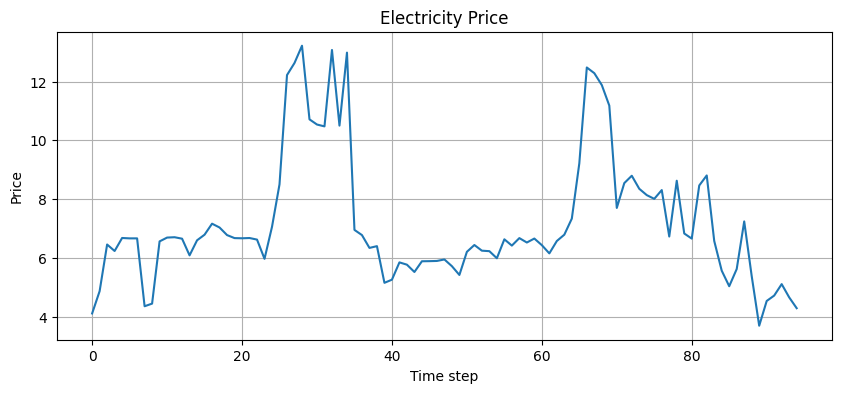

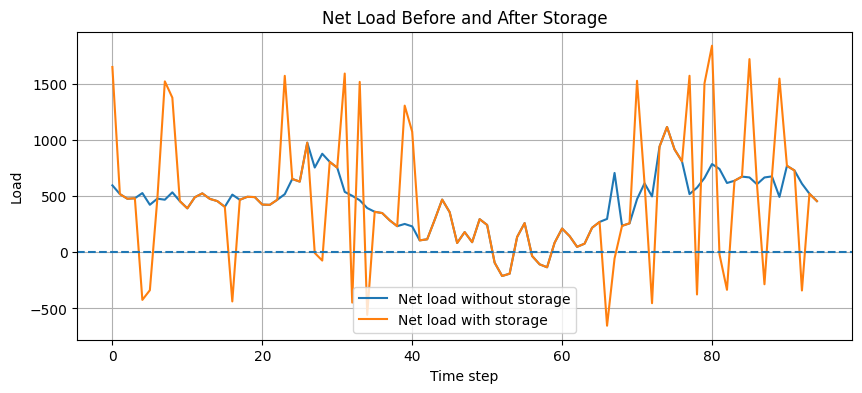

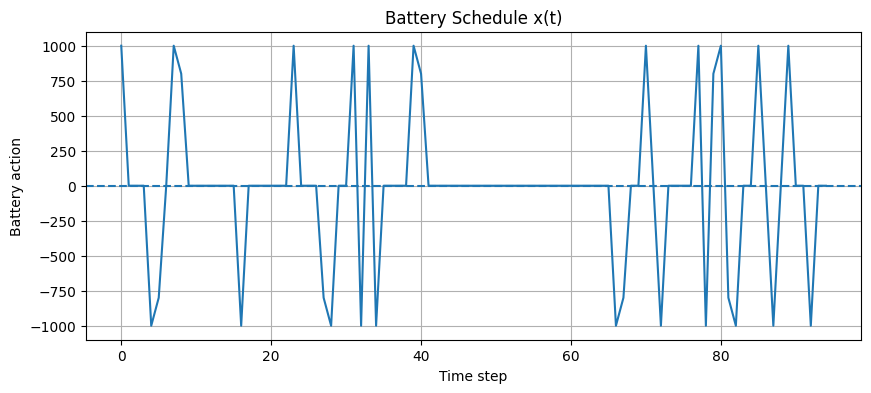

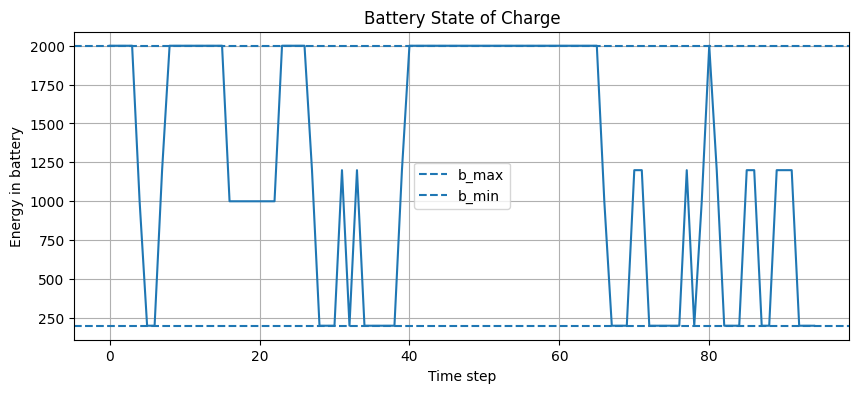

In [198]:

    # Plots
    plt.figure(figsize=(10, 4))
    plt.plot(real)
    plt.title("Electricity Price")
    plt.xlabel("Time step")
    plt.ylabel("Price")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(load, label='Net load without storage')
    plt.plot(lhouse, label='Net load with storage')
    plt.axhline(0, linestyle='--')
    plt.title("Net Load Before and After Storage")
    plt.xlabel("Time step")
    plt.ylabel("Load")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(x)
    plt.axhline(0, linestyle='--')
    plt.title("Battery Schedule x(t)")
    plt.xlabel("Time step")
    plt.ylabel("Battery action")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(soc)
    plt.axhline(b_max, linestyle='--', label='b_max')
    plt.axhline(b_min, linestyle='--', label='b_min')
    plt.title("Battery State of Charge")
    plt.xlabel("Time step")
    plt.ylabel("Energy in battery")
    plt.legend()
    plt.grid(True)
    plt.show()

Senstivity over k =[1,0.75.0.25,0]

   kappa  objective_value  cost_nominal  cost_with_battery  arbitrage_gain
0   1.00    277235.527374    313.198723         277.235527       35.963196
1   0.75    277142.157729    314.426186         277.142158       37.284028
2   0.50    277015.777162    315.653648         277.015777       38.637871
3   0.25    276848.157236    316.881111         276.848157       40.032954
4   0.00    276608.935872    318.108574         276.608936       41.499638


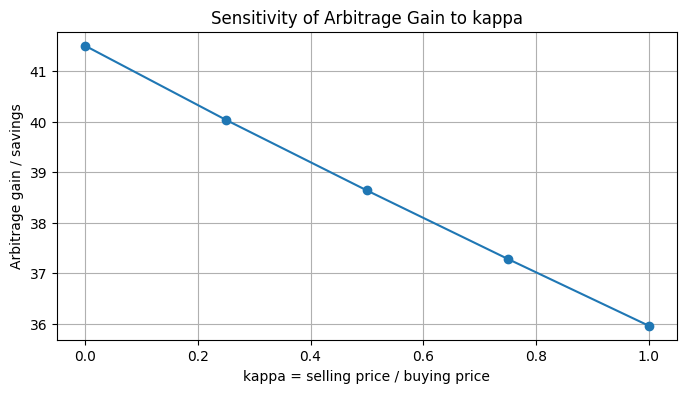

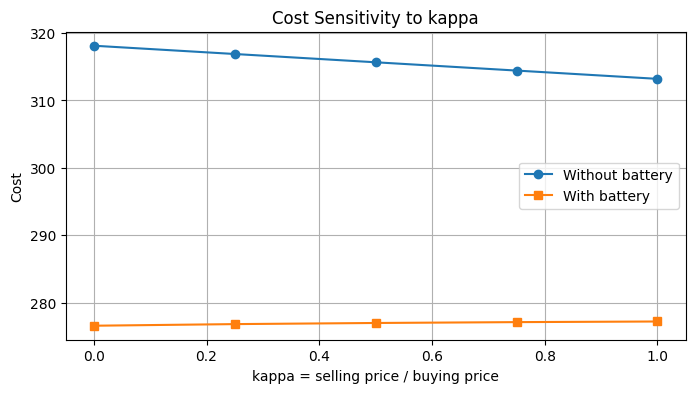

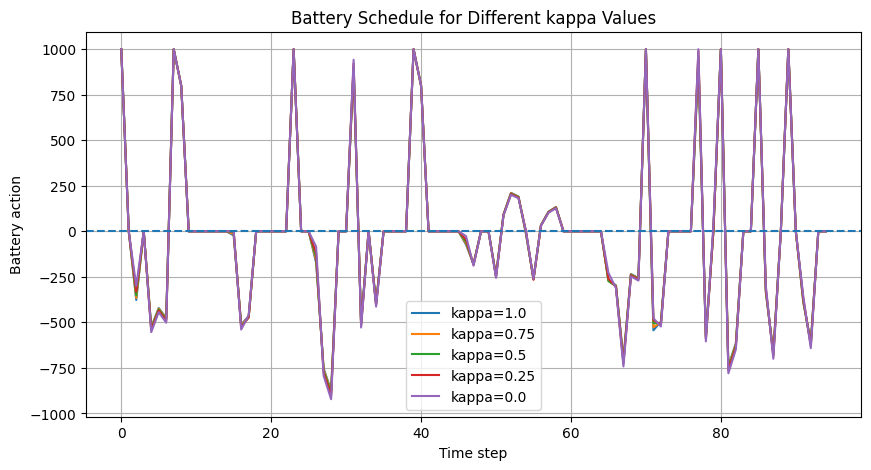

In [199]:
# # ============================================================
# df = pd.read_csv('data.csv')
# load = df.iloc[:, 0].to_numpy().squeeze()
# real = df.iloc[:, 1].to_numpy().squeeze()

# N = len(real)

# # ============================================================
# # BATTERY PARAMETERS
# # ============================================================
# e_ch = 0.95
# e_dis = 0.95
# del_max = 4000
# del_min = -del_max
# b_0 = 1000
# b_max = 2000
# b_min = 200
# h = 0.25

# Sensitivity values for kappa
kappa_values = [1.0, 0.75, 0.5, 0.25, 0.0]

# ============================================================
# STORAGE FOR RESULTS
# ============================================================
results = []
solutions = {}

def transaction_cost(net_load, price, kappa):
    return np.sum(
        price * np.maximum(net_load, 0) - kappa * price * np.maximum(-net_load, 0)
    ) / 1000

# ============================================================
# LOOP OVER KAPPA
# ============================================================
for kappa in kappa_values:

    K_import = -real * load
    K_export = kappa * real * load

    real_buy = real / e_ch
    real_discharge = real * e_dis
    real_export_charge = -kappa * real / e_ch
    real_export_discharge = -kappa * real * e_dis

    A_buy = np.diag(real_buy)
    A_sell = np.diag(real_export_discharge)
    A_interm = np.diag(real_discharge)
    A_intermnegload = np.diag(real_export_charge)
    A_minus = -np.eye(N)
    A_zero = np.zeros((N, N))

    L = np.tril(np.ones((N, N)), -1) + np.eye(N)

    # Full LP matrix
    A = np.vstack([
        np.hstack([A_buy, A_minus]),
        np.hstack([A_interm, A_minus]),
        np.hstack([A_intermnegload, A_minus]),
        np.hstack([A_sell, A_minus]),
        np.hstack([L, A_zero]),
        np.hstack([-L, A_zero])
    ])

    b = np.concatenate([
        K_import,
        K_import,
        K_export,
        K_export,
        (b_max - b_0) * np.ones(N),
        (b_0 - b_min) * np.ones(N)
    ])

    lb = np.concatenate([
        del_min * h * np.ones(N),
        -1_000_000 * np.ones(N)
    ])

    ub = np.concatenate([
        del_max * h * np.ones(N),
        1_000_000 * np.ones(N)
    ])

    bounds = list(zip(lb, ub))

    f = np.concatenate([
        np.zeros(N),
        np.ones(N)
    ])

    # Solve LP
    res = linprog(c=f, A_ub=A, b_ub=b, bounds=bounds, method='highs')

    if not res.success:
        print(f"Optimization failed for kappa={kappa}: {res.message}")
        results.append([kappa, np.nan, np.nan, np.nan, np.nan])
        continue

    x = res.x[:N]

    # Nominal cost without storage
    cost_nominal = transaction_cost(load, real, kappa)

    # Battery split
    x_ch = np.maximum(0, x)
    x_ds = -np.minimum(0, x)

    # Net load with battery
    lhouse = load + x_ch / e_ch - x_ds * e_dis

    # Cost with battery
    cost_with_battery = transaction_cost(lhouse, real, kappa)

    # Savings / arbitrage gain
    arbitrage_gain = cost_nominal - cost_with_battery

    # SOC
    soc = b_0 + np.cumsum(x)

    # Save scalar results
    results.append([
        kappa,
        res.fun,
        cost_nominal,
        cost_with_battery,
        arbitrage_gain
    ])

    # Save full solution for optional plots
    solutions[kappa] = {
        'x': x,
        'soc': soc,
        'lhouse': lhouse
    }

# ============================================================
# RESULTS TABLE
# ============================================================
results_df = pd.DataFrame(results, columns=[
    'kappa',
    'objective_value',
    'cost_nominal',
    'cost_with_battery',
    'arbitrage_gain'
])

print(results_df)

# ============================================================
# PLOT 1: ARBITRAGE GAIN VS KAPPA
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(results_df['kappa'], results_df['arbitrage_gain'], marker='o')
plt.xlabel('kappa = selling price / buying price')
plt.ylabel('Arbitrage gain / savings')
plt.title('Sensitivity of Arbitrage Gain to kappa')
plt.grid(True)
plt.show()

# ============================================================
# PLOT 2: COST WITHOUT AND WITH BATTERY
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(results_df['kappa'], results_df['cost_nominal'], marker='o', label='Without battery')
plt.plot(results_df['kappa'], results_df['cost_with_battery'], marker='s', label='With battery')
plt.xlabel('kappa = selling price / buying price')
plt.ylabel('Cost')
plt.title('Cost Sensitivity to kappa')
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# OPTIONAL: PLOT BATTERY SCHEDULES FOR EACH KAPPA
# ============================================================
plt.figure(figsize=(10, 5))
for kappa in kappa_values:
    if kappa in solutions:
        plt.plot(solutions[kappa]['x'], label=f'kappa={kappa}')
plt.axhline(0, linestyle='--')
plt.xlabel('Time step')
plt.ylabel('Battery action')
plt.title('Battery Schedule for Different kappa Values')
plt.legend()
plt.grid(True)
plt.show()

In [200]:
results_df['savings_percent'] = 100 * (
    results_df['cost_nominal'] - results_df['cost_with_battery']
) / results_df['cost_nominal']

print(results_df)

   kappa  objective_value  cost_nominal  cost_with_battery  arbitrage_gain  \
0   1.00    277235.527374    313.198723         277.235527       35.963196   
1   0.75    277142.157729    314.426186         277.142158       37.284028   
2   0.50    277015.777162    315.653648         277.015777       38.637871   
3   0.25    276848.157236    316.881111         276.848157       40.032954   
4   0.00    276608.935872    318.108574         276.608936       41.499638   

   savings_percent  
0        11.482549  
1        11.857800  
2        12.240591  
3        12.633430  
4        13.045746  
